### Initial Dataset Inspection

In [14]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv(r"C:\Users\ansar\OneDrive\Downloads\Bankruptcies.csv")

# Basic Information
print("Shape of Dataset:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df['Bankrupt?'].value_counts())

print("\nClass Percentage:")
print(round(df['Bankrupt?'].value_counts(normalize=True)*100,2))

Shape of Dataset: (6819, 96)

First 5 Rows:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    Af

### Target Variable Analysis & Class Imbalance Visualization

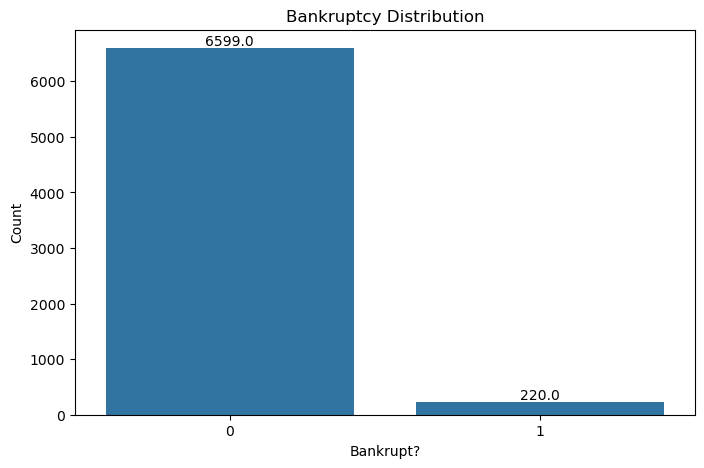

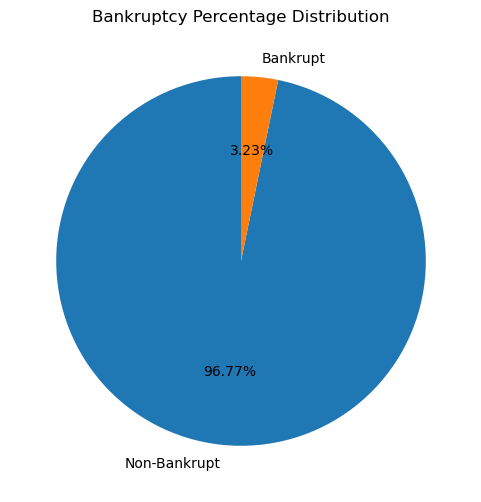

Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target Variable Distribution
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Bankrupt?', data=df)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title('Bankruptcy Distribution')
plt.xlabel('Bankrupt?')
plt.ylabel('Count')
plt.show()

# Percentage Distribution
bankruptcy_percent = df['Bankrupt?'].value_counts(normalize=True)*100

plt.figure(figsize=(6,6))
plt.pie(bankruptcy_percent,
        labels=['Non-Bankrupt','Bankrupt'],
        autopct='%1.2f%%',
        startangle=90)

plt.title('Bankruptcy Percentage Distribution')
plt.show()

print(bankruptcy_percent)

### Correlation Analysis & Top Bankruptcy Predictors

Top 20 Positive Correlations with Bankruptcy:
Bankrupt?                                       1.000000
 Debt ratio %                                   0.250161
 Current Liability to Assets                    0.194494
 Borrowing dependency                           0.176543
 Current Liability to Current Assets            0.171306
 Liability to Equity                            0.166812
 Current Liabilities/Equity                     0.153828
 Current Liability to Equity                    0.153828
 Liability-Assets Flag                          0.139212
 Total expense/Assets                           0.139049
 Equity to Long-term Liability                  0.139014
 Cash/Current Liability                         0.077921
 Inventory and accounts receivable/Net value    0.075278
 Fixed Assets Turnover Frequency                0.072818
 Contingent liabilities/Net worth               0.070455
 Fixed Assets to Assets                         0.066328
 Net Value Growth Rate                    

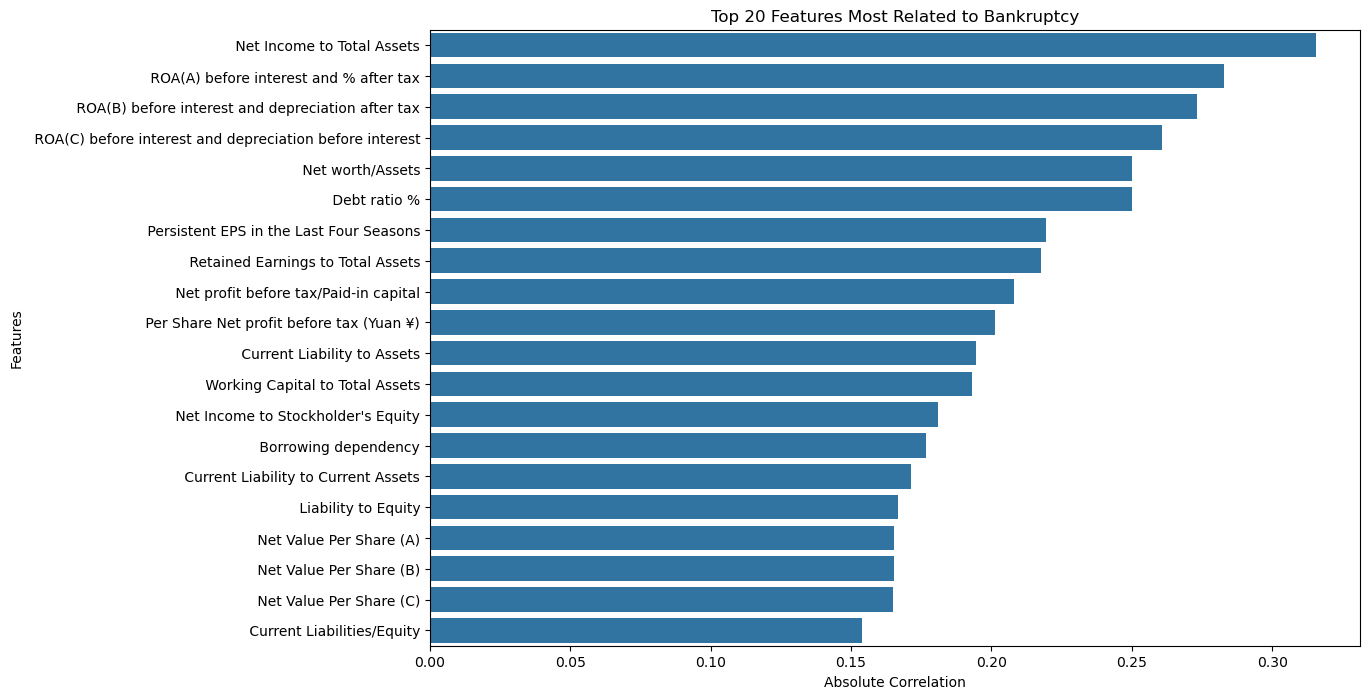

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation with target variable
target_corr = df.corr()['Bankrupt?'].sort_values(ascending=False)

print("Top 20 Positive Correlations with Bankruptcy:")
print(target_corr.head(20))

print("\nTop 20 Negative Correlations with Bankruptcy:")
print(target_corr.tail(20))

# Top correlated features excluding target
top_features = target_corr.abs().sort_values(ascending=False)[1:21]

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 20 Features Most Related to Bankruptcy")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")
plt.show()

### Feature Selection Heatmap

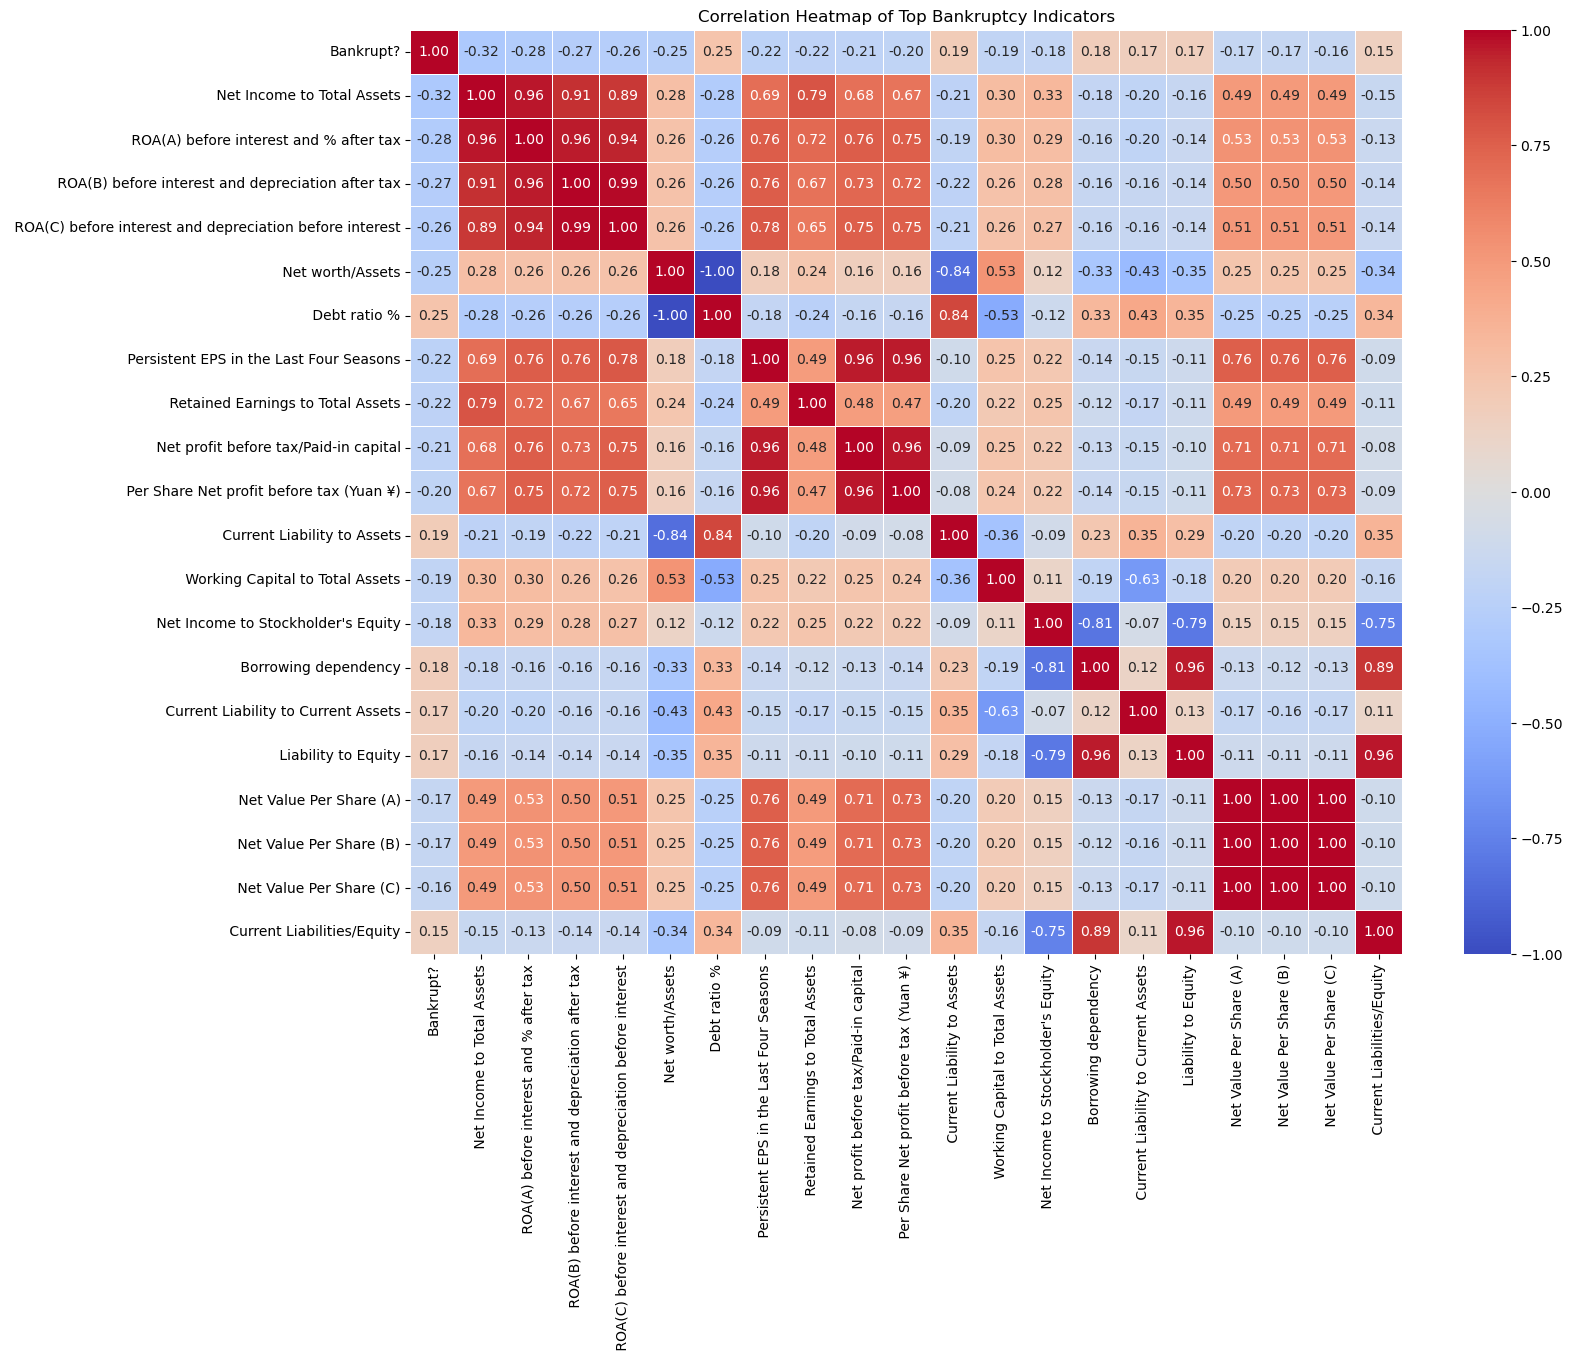

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 20 most correlated features
top_20 = target_corr.abs().sort_values(ascending=False)[1:21].index.tolist()

# Add target column
selected_features = ['Bankrupt?'] + top_20

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Top Bankruptcy Indicators')
plt.show()

### Remove Constant & Highly Correlated Features

In [18]:

nunique = df.nunique()
constant_columns = nunique[nunique == 1].index.tolist()

print("Constant Columns:")
print(constant_columns)

df_clean = df.drop(columns=constant_columns)

print("\nShape After Removing Constant Features:")
print(df_clean.shape)

Constant Columns:
[' Net Income Flag']

Shape After Removing Constant Features:
(6819, 95)


### Remove Highly Correlated Features

In [19]:
# Correlation Matrix
corr_matrix = df_clean.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Highly Correlated Features:")
print(to_drop)

df_final = df_clean.drop(columns=to_drop)

print("\nOriginal Shape:", df_clean.shape)
print("New Shape:", df_final.shape)

Highly Correlated Features:
[' ROA(B) before interest and depreciation after tax', ' Realized Sales Gross Margin', ' After-tax net Interest Rate', ' Continuous interest rate (after tax)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Per Share Net profit before tax (Yuan ¥)', ' Regular Net Profit Growth Rate', ' Net worth/Assets', ' Operating profit/Paid-in capital', ' Net profit before tax/Paid-in capital', ' Current Liability to Liability', ' Current Liability to Equity', ' Net Income to Total Assets', ' Gross Profit to Sales', ' Liability to Equity']

Original Shape: (6819, 95)
New Shape: (6819, 79)


### Undersampling

In [20]:
from sklearn.utils import resample

majority = df_final[df_final['Bankrupt?'] == 0]
minority = df_final[df_final['Bankrupt?'] == 1]

print("Before Sampling:")
print(df_final['Bankrupt?'].value_counts())

majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

balanced_df = pd.concat([majority_downsampled, minority])

print("\nAfter Undersampling:")
print(balanced_df['Bankrupt?'].value_counts())

print("\nBalanced Dataset Shape:")
print(balanced_df.shape)

Before Sampling:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

After Undersampling:
Bankrupt?
0    220
1    220
Name: count, dtype: int64

Balanced Dataset Shape:
(440, 79)


### Train-Test Split & Feature Scaling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = balanced_df.drop('Bankrupt?', axis=1)
y = balanced_df['Bankrupt?']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling Completed")

X_train Shape: (352, 78)
X_test Shape: (88, 78)

Scaling Completed


### Train Multiple Classification Models

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True, random_state=42)
}

print("Models Loaded Successfully")

Models Loaded Successfully


### Model Evaluation Comparison

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    if name in ["Logistic Regression","KNN","SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.875000   0.866667  0.886364  0.876404
5                  KNN  0.840909   0.840909  0.840909  0.840909
3    Gradient Boosting  0.829545   0.795918  0.886364  0.838710
6                  SVM  0.829545   0.795918  0.886364  0.838710
4             AdaBoost  0.829545   0.837209  0.818182  0.827586
0  Logistic Regression  0.818182   0.804348  0.840909  0.822222
1        Decision Tree  0.772727   0.740000  0.840909  0.787234


### Visual Comparison of Models

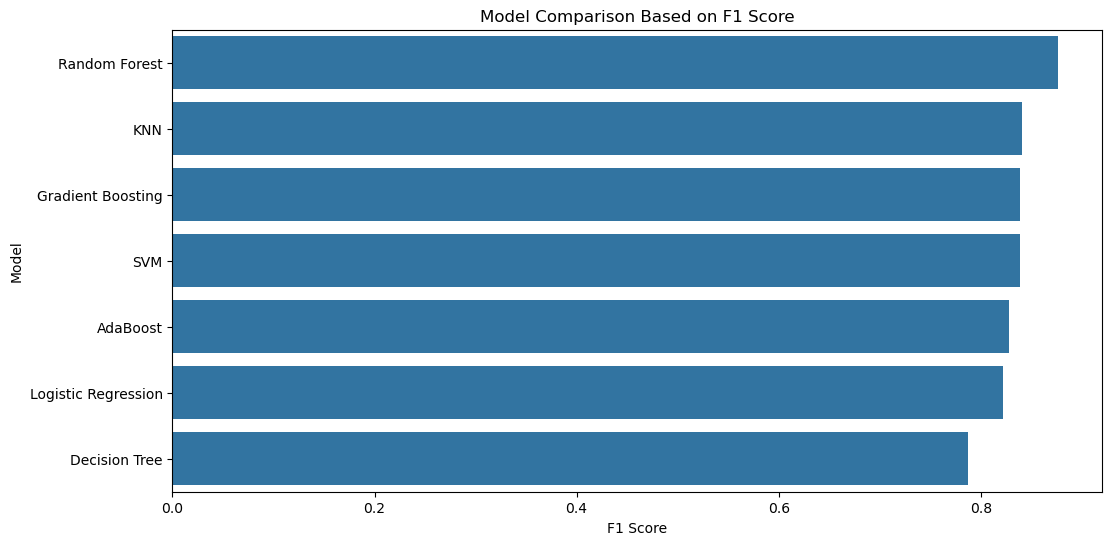

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='F1 Score',
    y='Model'
)

plt.title('Model Comparison Based on F1 Score')
plt.xlabel('F1 Score')
plt.ylabel('Model')

plt.show()

### Train Top 3 Models Again

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

rf = RandomForestClassifier(random_state=42)

gb = GradientBoostingClassifier(random_state=42)

knn = KNeighborsClassifier()

rf.fit(X_train, y_train)

gb.fit(X_train, y_train)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

### Voting Classifier

In [26]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(

    estimators=[

        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('knn', KNeighborsClassifier())

    ],

    voting='soft'
)

voting_model.fit(X_train_scaled, y_train)

y_pred_vote = voting_model.predict(X_test_scaled)

### Ensemble Evaluation

Accuracy: 0.8409090909090909
Precision: 0.8125
Recall: 0.8863636363636364
F1 Score: 0.8478260869565217

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.80      0.83        44
           1       0.81      0.89      0.85        44

    accuracy                           0.84        88
   macro avg       0.84      0.84      0.84        88
weighted avg       0.84      0.84      0.84        88



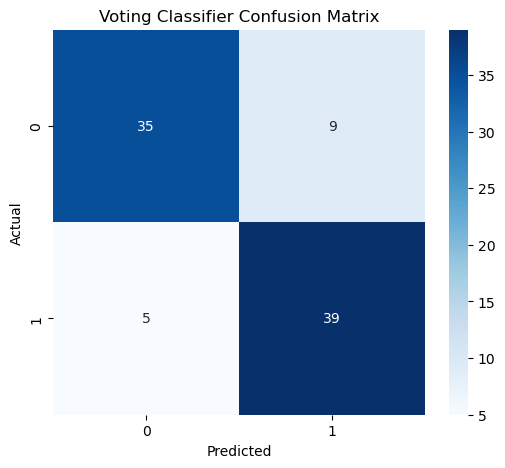

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_vote))

print("Precision:",
      precision_score(y_test, y_pred_vote))

print("Recall:",
      recall_score(y_test, y_pred_vote))

print("F1 Score:",
      f1_score(y_test, y_pred_vote))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_vote))

cm = confusion_matrix(y_test, y_pred_vote)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Voting Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Hyperparameter Tuning of Random Forest

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV F1 Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

Best CV F1 Score:
0.8766768752419125


### Evaluate Tuned Model

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8522727272727273
Precision: 0.8297872340425532
Recall: 0.8863636363636364
F1 Score: 0.8571428571428571

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        44
           1       0.83      0.89      0.86        44

    accuracy                           0.85        88
   macro avg       0.85      0.85      0.85        88
weighted avg       0.85      0.85      0.85        88



### Feature Importance Analysis

                                              Feature  Importance
56                  Retained Earnings to Total Assets    0.073146
57                         Total income/Total expense    0.067324
30                               Borrowing dependency    0.063832
25                                        Quick Ratio    0.051996
0    ROA(C) before interest and depreciation befor...    0.049261
28                                       Debt ratio %    0.048216
4                           Pre-tax net Interest Rate    0.042421
74                 Net Income to Stockholder's Equity    0.041874
11                            Net Value Per Share (B)    0.041544
27                         Total debt/Total net worth    0.040855
12            Persistent EPS in the Last Four Seasons    0.033559
1              ROA(A) before interest and % after tax    0.031057
5         Non-industry income and expenditure/revenue    0.029354
75                 Degree of Financial Leverage (DFL)    0.023253
77        

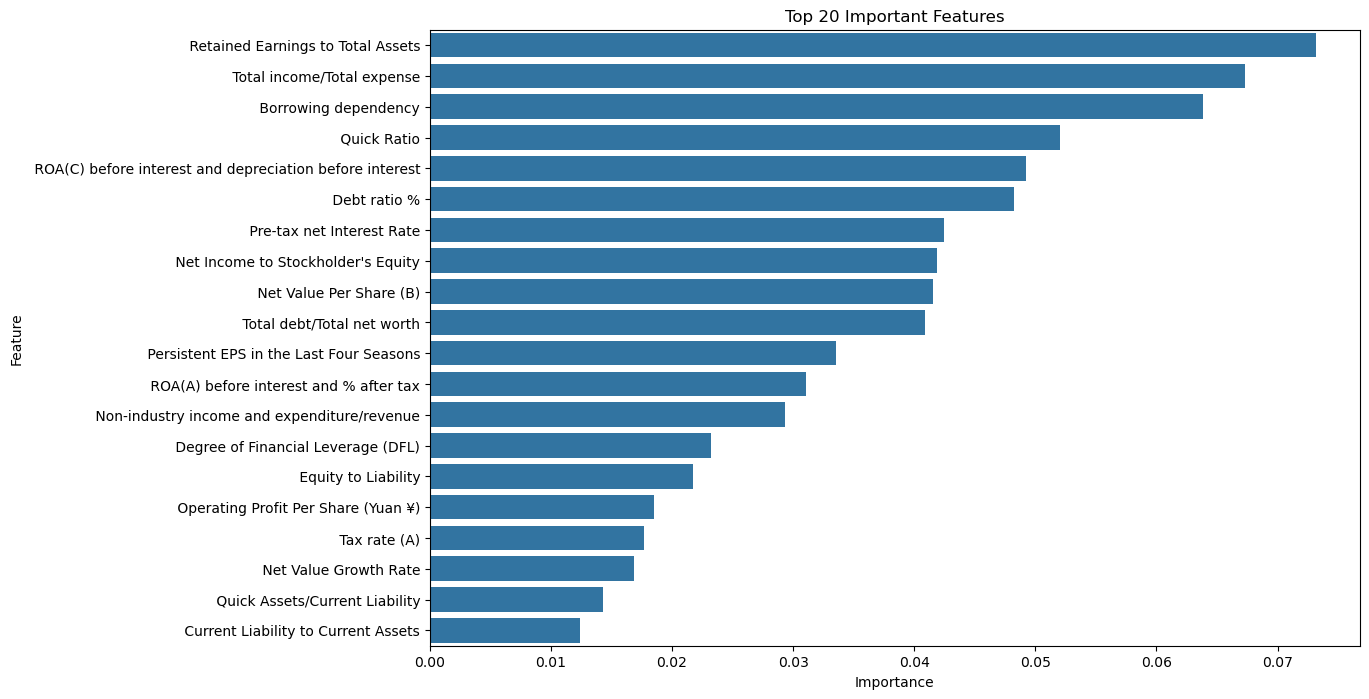

In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Important Features")
plt.show()

### Created For Real case Example

In [31]:
new_company = pd.DataFrame([X.mean()])

new_company[' Debt ratio %'] = 0.80
new_company[' Borrowing dependency'] = 0.85
new_company[' Quick Ratio'] = 0.30
new_company[' Retained Earnings to Total Assets'] = 0.10
new_company[' Total income/Total expense'] = 0.70

In [32]:
prediction = best_rf.predict(new_company)

probability = best_rf.predict_proba(new_company)

print("Prediction:", prediction[0])
print("Bankruptcy Probability:", round(probability[0][1]*100, 2), "%")

Prediction: 1
Bankruptcy Probability: 68.74 %


### Better Example

In [33]:
sample_company = X_test.iloc[[0]]

prediction = best_rf.predict(sample_company)

probability = best_rf.predict_proba(sample_company)

print("Actual Class:", y_test.iloc[0])
print("Predicted Class:", prediction[0])
print("Bankruptcy Probability:", round(probability[0][1]*100, 2), "%")

Actual Class: 1
Predicted Class: 1
Bankruptcy Probability: 74.19 %


In [34]:
import joblib

joblib.dump(best_rf, 'bankruptcy_model.pkl')

['bankruptcy_model.pkl']